# Preamble

In [69]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"  # Add this before any torch imports
import cv2 as cv
import numpy as np
from PIL import Image
import pandas as pd
from torchvision.transforms import transforms
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from torch import nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

%matplotlib inline

# Preparing Data for Training

In [ ]:
image_path = [[],[]]
labels = [[],[]]

# Folder produced by src/augment.py — contains train/ and val/ subfolders,
# each with one subfolder per class.
input_path = 'data/train_val_Split_Output'

j = 0

for dataset in os.listdir(input_path):
    for label in os.listdir(os.path.join(input_path,dataset)):
        for image in os.listdir(os.path.join(input_path,dataset,label)):
            image_path[j].append(os.path.join(input_path,dataset,label,image))
            labels[j].append(label)
    j += 1

In [112]:
train_df = pd.DataFrame({'image_path':image_path[0],'label':labels[0]})
# test_df = pd.DataFrame({'image_path':image_path[0],'label':labels[0]})
val_df = pd.DataFrame({'image_path':image_path[1],'label':labels[1]})

full_frame = pd.concat([train_df,val_df])

print(full_frame['label'].unique())

# LabelEncoder() object fits labels with an interger from 0 to n_labels-1
label_encoder = LabelEncoder()
label_encoder.fit(full_frame['label'])

['KEK_LAPIS' 'KUIH_KASWI_PANDAN' 'KUIH_KETAYAP' 'KUIH_LAPIS'
 'KUIH_SERI_MUKA' 'KUIH_TALAM' 'KUIH_UBI_KAYU' 'ONDE_ONDE']


LabelEncoder()

In [113]:
train_labels = label_encoder.transform(train_df['label'])
print("Train labels min/max:", np.min(train_labels), np.max(train_labels))

Train labels min/max: 0 7


In [114]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.RandomErasing(p=0.3),
    transforms.ColorJitter(brightness=0.3),
    # this is the mean and standard deviation for [R,G,B] of the imagenet dataset
    # we can do better normalisation by using the mean and std dev of our
    # dataset
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224)),
    transforms.ConvertImageDtype(torch.float32),
    # this is the mean and standard deviation for [R,G,B] of the imagenet dataset
    # we can do better normalisation by using the mean and std dev of our
    # dataset
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [115]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    # transform = None initialises default transform as None
    self.dataframe = dataframe
    self.transform = transform
    # transform text labels into numerical labels
    # Keep labels on CPU (do NOT use .to(device) here)
    self.labels = torch.tensor(label_encoder.transform(dataframe["label"]))

  def __getitem__(self, index):
    # iloc[a,b] returns index at [row = a, column = b]
    # note that axis 0 refers to rows and axis 1 refers to columns
    row = self.dataframe.iloc[index]
    img_path = row["image_path"]
    label = self.labels[index]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      # Keep labels on CPU (do NOT use .to(device) here)
      image = self.transform(image)
    #both image and label on cpu
    return image, label

  def __len__(self):
    #returns how many rows you have in dataframe
    return len(self.dataframe)

In [116]:
train_dataset = CustomImageDataset(train_df, train_transform)
# test_dataset = CustomImageDataset(test_df, transform)
val_dataset = CustomImageDataset(val_df, val_transform)

In [117]:
print(train_dataset[0][0].shape)

torch.Size([3, 224, 224])


### **HYPERPARAMETERS**

In [171]:
# learning rate
LR = 1e-4
# batch size
BATCH_SIZE = 16
# number of epochs
EPOCHS = 10
# L2 lambda
WEIGHT_DECAY = 0.001471975670040013
#SGD momentum
momentum = 0.9

### Defining DataLoaders

In [172]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Model

In [173]:
from torchvision import models
from torchvision.models import ResNet50_Weights

In [174]:
# resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
#  #Example to print the names of each layer block
# for name, layer in resnet.named_children():
#     print(f'{name}')

In [175]:
class CustomResNet(nn.Module):
    def __init__(self):
        super(CustomResNet, self).__init__()
        self.resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

#        Freeze ALL RESNET Layers
        # for param in self.resnet.parameters():
        #    param.requires_grad = False
        
#        Freeze layers up to `layer4`
        for name, param in self.resnet.named_parameters():
            if "layer3" not in name and "layer4" not in name:
                param.requires_grad = False 
        
        self.resnet.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.42379873478251573),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.42379873478251573),
            nn.Linear(512, 8)
         )
    def forward(self, x):
        x = self.resnet(x)
        x = self.classifier(x)
        return x

In [176]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CustomResNet().to(device)
from torchsummary import summary
summary(model, input_size = (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

# Training

In [177]:
model = CustomResNet().to(device)
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(),lr = LR,weight_decay=WEIGHT_DECAY)
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=momentum, weight_decay = WEIGHT_DECAY)

In [185]:
epoch_loss_train_plot = []
epoch_loss_val_plot = []
epoch_acc_train_plot = []
epoch_acc_val_plot = []

batch_loss_train_plot = []
batch_loss_val_plot = []
batch_acc_train_plot = []
batch_acc_val_plot = []

since = time.time()
total_time = 0

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch+1}')

    epoch_loss_train = 0
    epoch_loss_val = 0
    epoch_acc_train = 0
    epoch_acc_val = 0

    batch_no = 1

    model.train()
    
    for inputs_train, labels_train in train_loader:

        print(inputs_train.size(0))
    
        batch_train_loss = 0
        batch_train_acc = 0
        batch_val_loss = 0
        batch_val_acc = 0

        inputs_train, labels_train = inputs_train.to(device), labels_train.to(device)
        outputs_train = model(inputs_train)
        loss_train = criterion(outputs_train, labels_train)
        '''
        this initialises the gradients of all the parameters to zero to prevent
        gradient accumulation
        https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch
        '''
        # optimizer.zero_grad()
        # Assigning gradient to None instead of 0 uses assignment instead of addition
        # for future backward passes, reducing the number of memory operations
        for param in model.parameters():
          param.grad = None
        ''''
        loss.backwards() computes the loss gradients of every parameter and stores
        them in the tensor.grad attribute for every parameter in the model.
        https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html
        '''
        loss_train.backward()
        '''
        optimizer.step() adjusts the parameters of the model based on the loss
        gradients stored in the tensors previously through loss.backwards()
        '''
        optimizer.step()

        batch_train_loss = loss_train.item()
        batch_train_acc = (torch.argmax(outputs_train, axis = 1) == labels_train).sum().item()
        
        epoch_loss_train += batch_train_loss
        epoch_acc_train += batch_train_acc
        
        batch_loss_train_plot.append(batch_train_loss)
        batch_acc_train_plot.append(batch_train_acc/BATCH_SIZE)

    model.eval()
    
    with torch.no_grad():
        
        for inputs_val, labels_val in val_loader:
            
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)
            
            batch_val_loss = loss_val.item()
            batch_val_acc = (torch.argmax(outputs_val, axis = 1) == labels_val).sum().item()
            
            epoch_loss_val += batch_val_loss
            epoch_acc_val += batch_val_acc

    epoch_loss_train_plot.append(epoch_loss_train/len(train_loader))
    epoch_loss_val_plot.append(epoch_loss_val/len(val_loader))
    epoch_acc_train_plot.append(epoch_acc_train/len(train_dataset))
    epoch_acc_val_plot.append(epoch_acc_val/len(val_dataset))

    time_elapsed = time.time() - since

    total_time += time_elapsed
    
    print(f'''
    Total Training Loss: {epoch_loss_train_plot[epoch]}
    Total Training Accuracy: {epoch_acc_train_plot[epoch]}
    Total Validation Loss: {epoch_loss_val_plot[epoch]}
    Total Validation Accuracy: {epoch_acc_val_plot[epoch]}
    
    {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s
    ''')

avg_time = total_time/EPOCHS
print(avg_time)

Epoch: 1
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16
16


KeyboardInterrupt: 

In [179]:
print(epoch_loss_train_plot)
print(epoch_loss_val_plot)
print(epoch_acc_train_plot) 
print(epoch_acc_val_plot)

[2.0446879076957702, 1.8480502394835154, 1.2572378743357129, 0.6992350869377454, 0.4415619914399253, 0.31260920101155837, 0.2257000534898705, 0.18808248176963793, 0.15330031705347613, 0.12442153941115572]
[1.9624176746920536, 1.470220280321021, 0.6700986843360098, 0.3312543516880588, 0.1925544331928617, 0.12330652743970093, 0.10942972404882312, 0.09534301667621262, 0.09814919327312198, 0.08729902248658043]
[0.2304861111111111, 0.47444444444444445, 0.6529861111111112, 0.7874305555555555, 0.8645833333333334, 0.9052083333333333, 0.9295138888888889, 0.9427777777777778, 0.9579166666666666, 0.9626388888888889]
[0.5866666666666667, 0.705, 0.8333333333333334, 0.9116666666666666, 0.9616666666666667, 0.97, 0.9766666666666667, 0.98, 0.9766666666666667, 0.9766666666666667]


# Test & Analysis

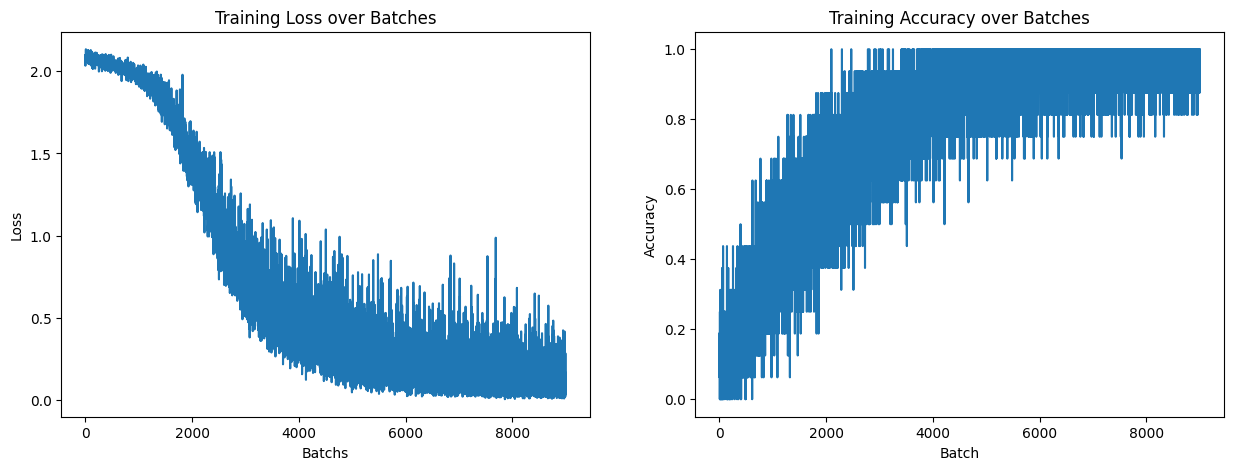

In [180]:
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axs[0].plot(batch_loss_train_plot,label="Training Loss")
axs[0].set_title("Training Loss over Batches")
axs[0].set_xlabel("Batchs")
axs[0].set_ylabel("Loss")

axs[1].plot(batch_acc_train_plot,label="Training Accuracy")
axs[1].set_title("Training Accuracy over Batches")
axs[1].set_xlabel("Batch")
axs[1].set_ylabel("Accuracy")

plt.savefig('[v] batch_v10 (RESNET).png')

plt.show()

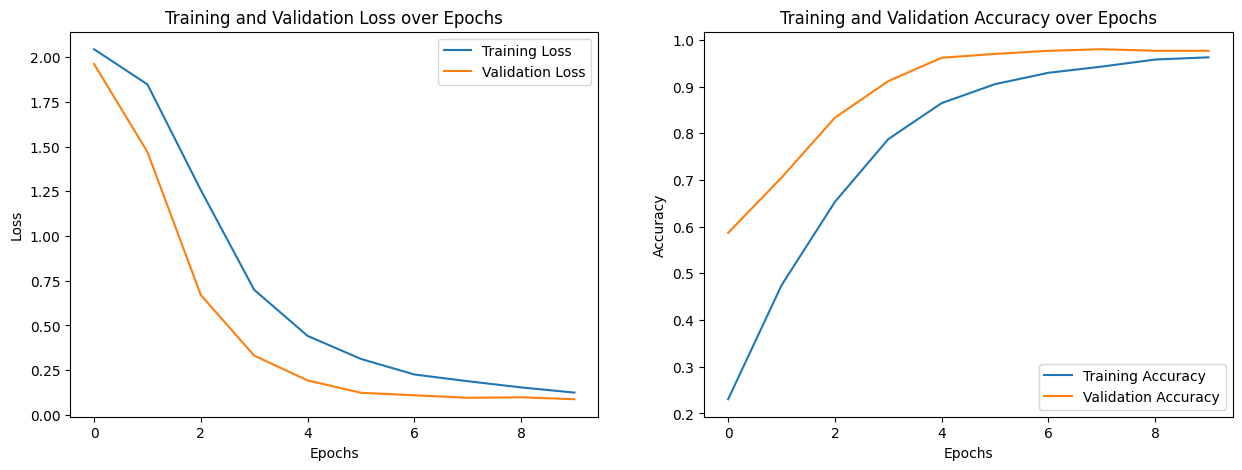

In [181]:
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axs[0].plot(epoch_loss_train_plot,label="Training Loss")
axs[0].plot(epoch_loss_val_plot,label="Validation Loss")
axs[0].legend()
axs[0].set_title("Training and Validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")

axs[1].plot(epoch_acc_train_plot,label="Training Accuracy")
axs[1].plot(epoch_acc_val_plot,label="Validation Accuracy")
axs[1].legend()
axs[1].set_title("Training and Validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")

plt.savefig('[v] epoch_v10 (RESNET).png')
 
plt.show()

# Save & Export

In [ ]:
#print("Model's state_dict:")
#for param_tensor in model.state_dict():
#    print(param_tensor, '\t', model.state_dict()[param_tensor].size())

In [ ]:
# Print optimizer's state_dict
#print("Optimizer's state_dict:")
#for var_name in optimizer.state_dict():
#    print(var_name, "\t", optimizer.state_dict()[var_name])

In [ ]:
torch.save(model.state_dict(), 'models/model_statedict.pt')

In [ ]:
torch.save(model, 'models/model_entire.pt')

In [ ]:
#torch.save(model.state_dict(), '')